In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from pandas.tseries.offsets import MonthEnd

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
df = pd.read_csv("BrentOilPrices.csv")

print("Dataset Shape:", df.shape)
print()

print("Column Names:", df.columns)
print()

print("First 5 Rows:")
display(df.head())
print()

print("Data Types:")
print(df.dtypes)
print()

print("Missing Values:")
print(df.isnull().sum())

Dataset Shape: (9011, 2)

Column Names: Index(['Date', 'Price'], dtype='object')

First 5 Rows:


,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63



Data Types:
Date      object
Price    float64
dtype: object

Missing Values:
Date     0
Price    0
dtype: int64


The dataset seems to be already clean, as there are no missing and duplicate values/records. It also shows that there are only 2 columns: one being DATE (object type, most likely needs to be converted to datetime and set as the index) and the other being the PRICE on said date (price is a float ($) and will most likely remain as a float until further notice).

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df = df.set_index('Date')

display(df.head())

print(df.index)

,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


DatetimeIndex(['1987-05-20', '1987-05-21', '1987-05-22', '1987-05-25',
               '1987-05-26', '1987-05-27', '1987-05-28', '1987-05-29',
               '1987-06-01', '1987-06-02',
               ...
               '2022-11-01', '2022-11-02', '2022-11-03', '2022-11-04',
               '2022-11-07', '2022-11-08', '2022-11-09', '2022-11-10',
               '2022-11-11', '2022-11-14'],
              dtype='datetime64[ns]', name='Date', length=9011, freq=None)


As expected, the date column was converted to datetime type and we chose the date column as the index. This is essential and standard practice for the time series analysis that we will perform.

In [4]:
print("Detected Frequency:")
print(pd.infer_freq(df.index))

Detected Frequency:
None


In [5]:
full_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='D'
)

missing_dates = full_range.difference(df.index)

print("Missing Dates Count:")
print(len(missing_dates))

print("\nFirst 10 Missing Dates:")
print(missing_dates[:10])

Missing Dates Count:
3952

First 10 Missing Dates:
DatetimeIndex(['1987-05-23', '1987-05-24', '1987-05-30', '1987-05-31',
               '1987-06-06', '1987-06-07', '1987-06-13', '1987-06-14',
               '1987-06-15', '1987-06-20'],
              dtype='datetime64[ns]', freq=None)


Here, we are seeing if the dataset is skipping days. We want to see what the original pattern or frequency of the dates captured is; this will make things clearer for us and help us in making a monthly forecast. Judging by the "None" detected frequency, that tells us that there are skipped dates and that there is no fixed or strict frequency.

In [6]:
monthly_df = df.resample('M').mean()

display(monthly_df.head())

print("Monthly Dataset Shape:")
print(monthly_df.shape)

,Price
Date,
1987-05-31,18.580000
1987-06-30,18.860476
1987-07-31,19.856522
1987-08-31,18.979524
1987-09-30,18.313182


Monthly Dataset Shape:
(427, 1)


Since the project calls for monthly forecasting of oil prices, we will give each month its average oil price and set that as the price. Using a monthly average will remove daily noise and give a cleaner and more insightful result for the project's objective. Note, rows were reduced down to 427 months.

In [7]:
print("Monthly Shape: ",monthly_df.shape)

print("Missing Values:")
print(monthly_df.isnull().sum())

print("Start Date: ",monthly_df.index.min())

print("End Date: ",monthly_df.index.max())

Monthly Shape:  (427, 1)
Missing Values:
Price    0
dtype: int64
Start Date:  1987-05-31 00:00:00
End Date:  2022-11-30 00:00:00


Performed general validation to make sure data is clean and ready for EDA.

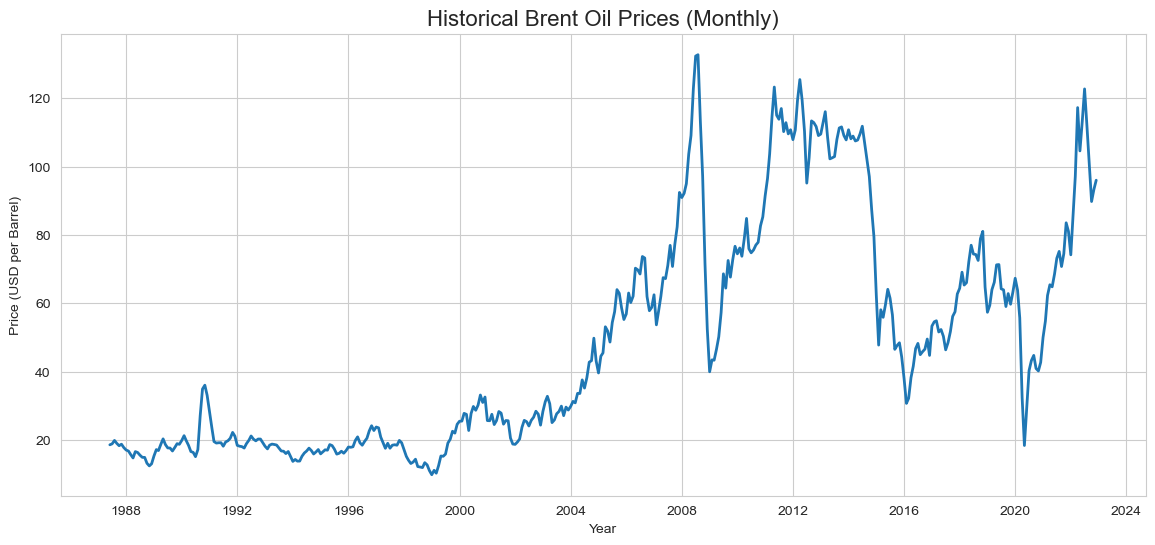

In [8]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_df.index,
    monthly_df['Price'],
    linewidth=2
)

plt.title('Historical Brent Oil Prices (Monthly)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (USD per Barrel)')

plt.grid(True)

plt.show()

The figure illustrates the long-term market behavior of oil prices (USD per barrel) from the year 1987 to 2022. We see that the overall general trend is that oil prices have increased over time, indicating increasing global energy demand, with spikes and fluctuations across different years. This leads us to believe that in these specific years, the stability was interrupted by economic disruptions and geopolitical influences.

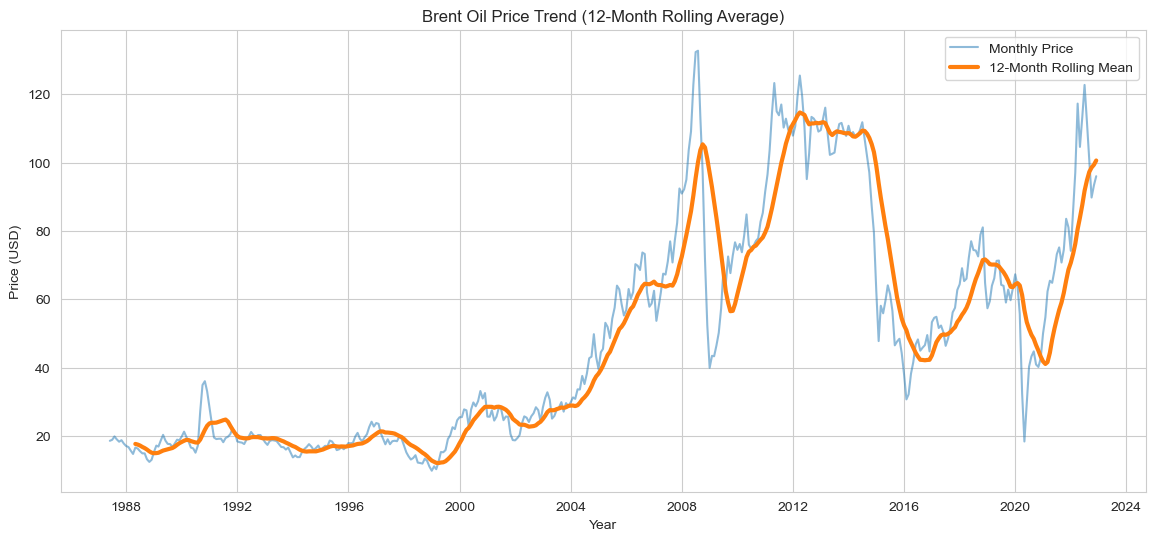

In [9]:
monthly_df['Rolling12'] = (
    monthly_df['Price']
    .rolling(window=12)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_df.index,
    monthly_df['Price'],
    alpha=0.5,
    label='Monthly Price'
)

plt.plot(
    monthly_df.index,
    monthly_df['Rolling12'],
    linewidth=3,
    label='12-Month Rolling Mean'
)

plt.title('Brent Oil Price Trend (12-Month Rolling Average)')
plt.xlabel('Year')
plt.ylabel('Price (USD)')

plt.legend()

plt.grid(True)

plt.show()

This visualization features a 12-month rolling average that smooths out the noise and shows a clearer trend. Our model will also perform better when we have a better understanding of the trend and long-term pattern.

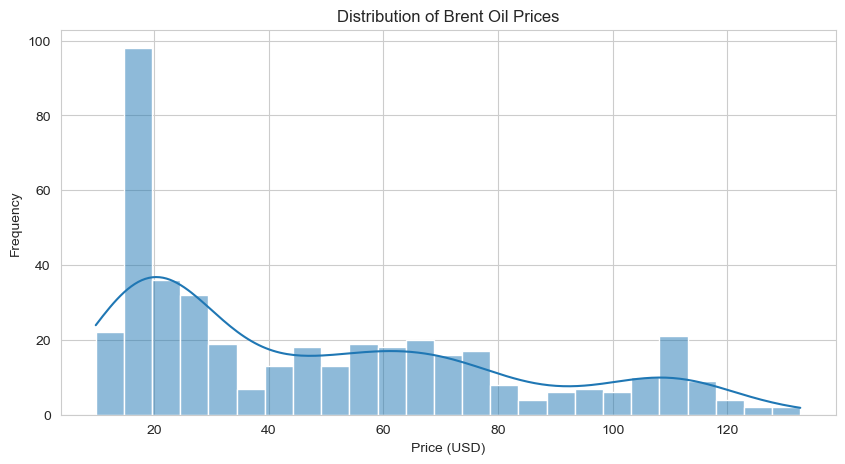

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    monthly_df['Price'],
    bins=25,
    kde=True
)

plt.title('Distribution of Brent Oil Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')

plt.show()

In this distribution plot, we are investigating the distribution of oil prices and, as expected, it's not normally distributed. This helps us identify skewness and outliers, and we clearly see that the distribution is skewed to the right, since a higher number of observations is occurring at lower prices and fewer observations at high oil prices.

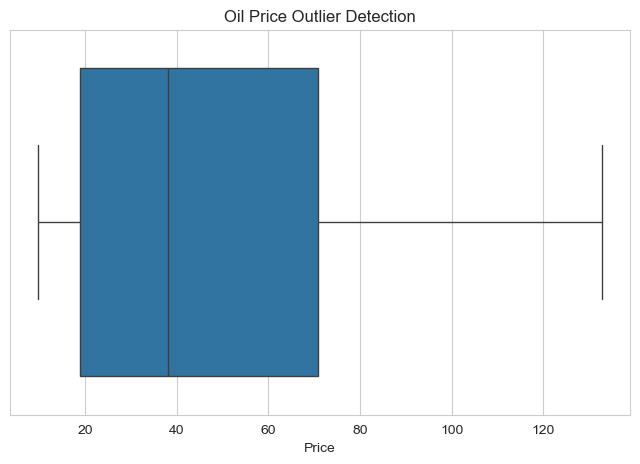

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=monthly_df['Price']
)

plt.title('Oil Price Outlier Detection')

plt.show()

This boxplot shows oil price outliers and provides more descriptive insights.

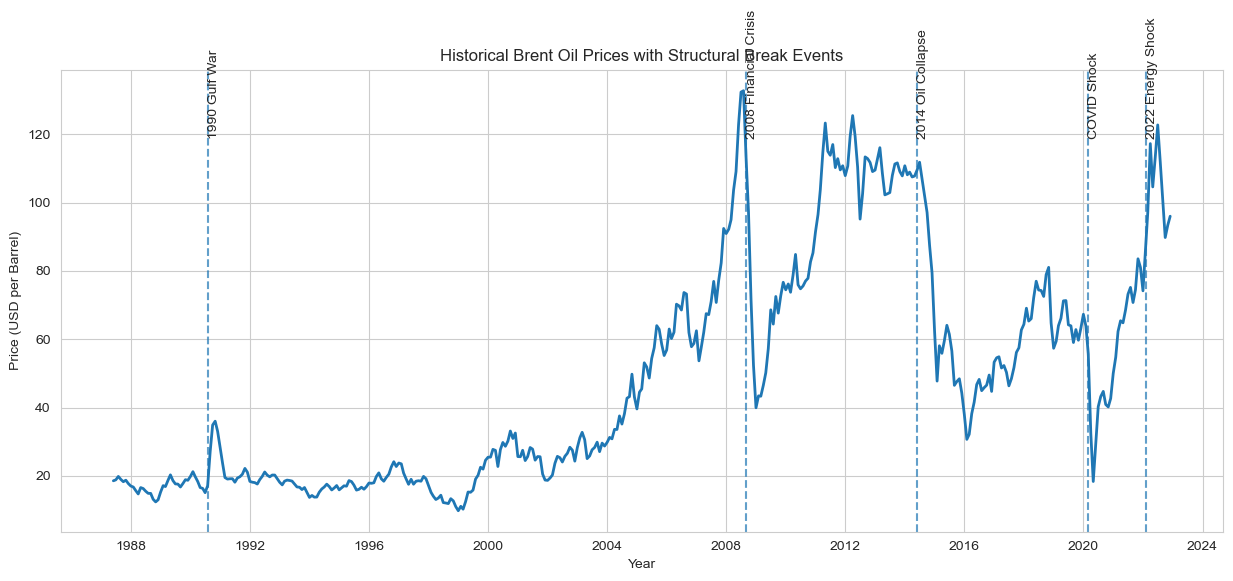

In [12]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_df.index,
    monthly_df['Price'],
    linewidth=2
)

events = {
    '1990 Gulf War':'1990-08',
    '2008 Financial Crisis':'2008-09',
    '2014 Oil Collapse':'2014-06',
    'COVID Shock':'2020-03',
    '2022 Energy Shock':'2022-02'
}

for label, date in events.items():

    plt.axvline(
        pd.to_datetime(date),
        linestyle='--',
        alpha=0.7
    )

    plt.text(
        pd.to_datetime(date),
        monthly_df['Price'].max()*0.9,
        label,
        rotation=90
    )

plt.title(
    'Historical Brent Oil Prices with Structural Break Events'
)

plt.xlabel('Year')
plt.ylabel('Price (USD per Barrel)')

plt.show()

This figure/visualization is very insightful as it illustrates the effects that global economic/historical events had on oil price forecasting and establishes a connection between them.

These events include: The Gulf War (1990), 2008 Financial Crisis, 2014 Oil Collapse, 2020 COVID Shock, and the 2022 Energy Shock.

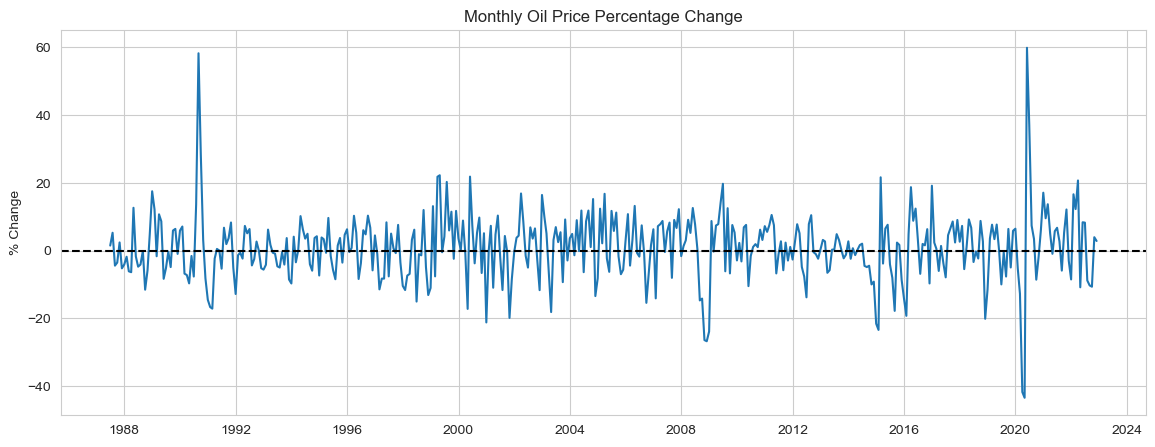

In [13]:
monthly_df['Monthly_Return'] = (
    monthly_df['Price']
    .pct_change()
    *100
)

plt.figure(figsize=(14,5))

plt.plot(
    monthly_df.index,
    monthly_df['Monthly_Return']
)

plt.axhline(
    0,
    color='black',
    linestyle='--'
)

plt.title('Monthly Oil Price Percentage Change')

plt.ylabel('% Change')

plt.show()

This figure/visualization measures the volatility by looking at the monthly oil price percentage change. The large spikes indicate instability and structural breaks or disruptions in patterns.

In [14]:
monthly_df['Log_Price'] = np.log(monthly_df['Price'])

monthly_df[['Price','Log_Price']].head()

,Price,Log_Price
Date,,
1987-05-31,18.580000,2.922086
1987-06-30,18.860476,2.937069
1987-07-31,19.856522,2.988533
1987-08-31,18.979524,2.943361
1987-09-30,18.313182,2.907621


To help our ARIMA model perform better, we should try to stabilize the oil prices, since ARIMA models assume that a time series should be stationary, and we know that our data is NOT stationary. We use log transformation to stabilize the oil prices.

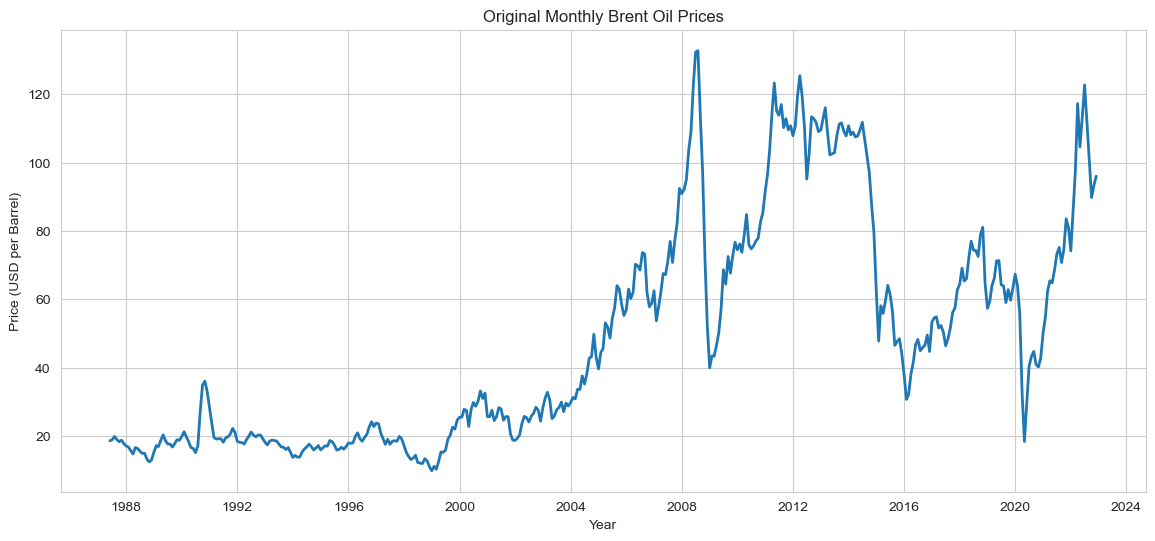

In [29]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_df.index,
    monthly_df['Price'],
    linewidth=2
)

plt.title('Original Monthly Brent Oil Prices')
plt.xlabel('Year')
plt.ylabel('Price (USD per Barrel)')

plt.grid(True)
plt.show()

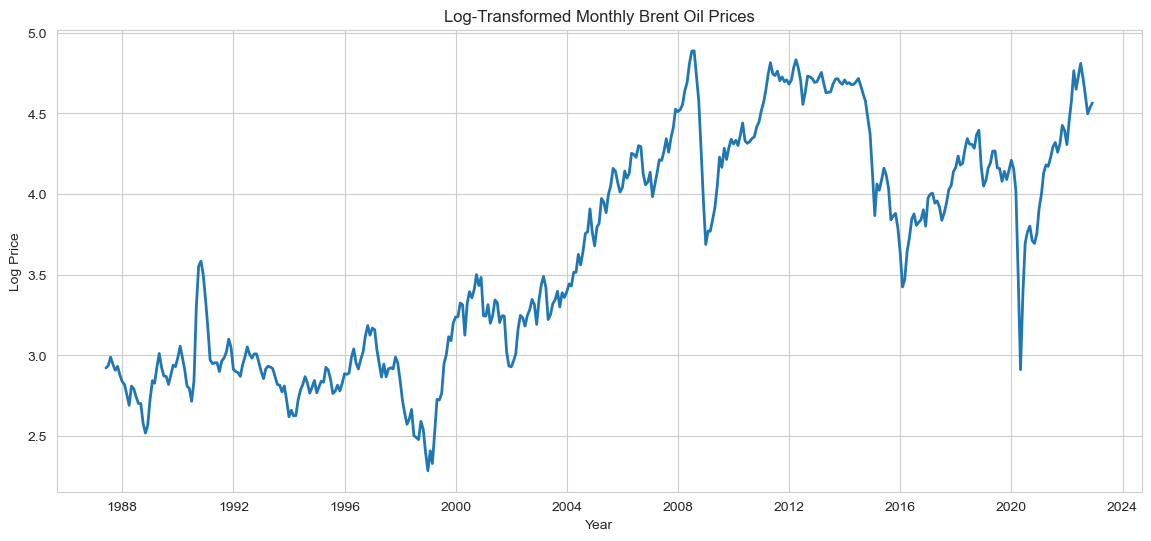

In [30]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_df.index,
    monthly_df['Log_Price'],
    linewidth=2
)

plt.title('Log-Transformed Monthly Brent Oil Prices')
plt.xlabel('Year')
plt.ylabel('Log Price')

plt.grid(True)
plt.show()

The log-transformed series follows a identical overall trend of the original Brent oil price plot. However, the transformation was applied primarily to stabilize variance and improve the statistical properties required for ARIMA modeling.

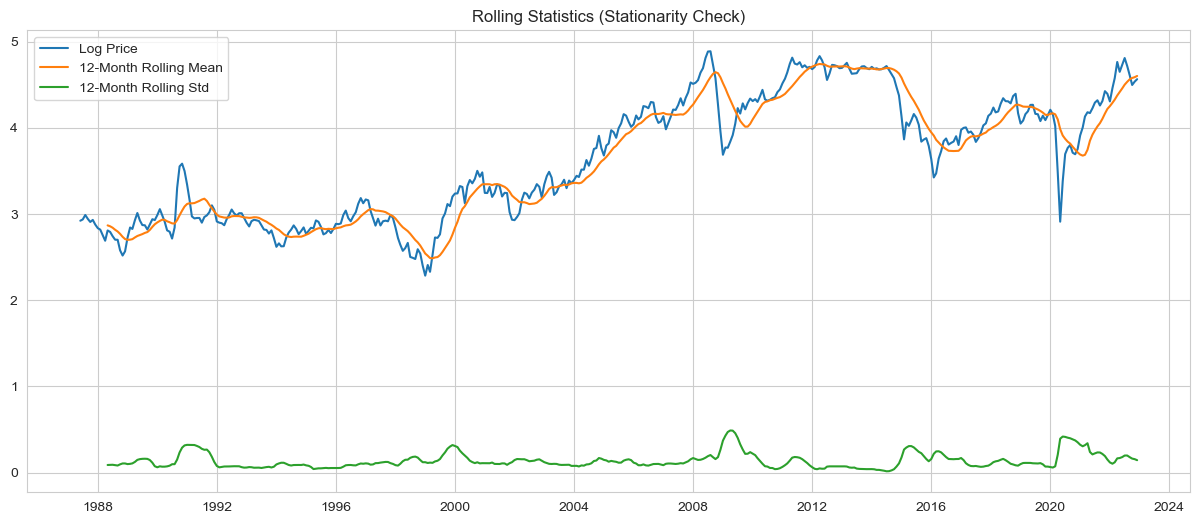

In [16]:
monthly_df['Rolling_Mean_12'] = (
    monthly_df['Log_Price']
    .rolling(12)
    .mean()
)

monthly_df['Rolling_STD_12'] = (
    monthly_df['Log_Price']
    .rolling(12)
    .std()
)

plt.figure(figsize=(15,6))

plt.plot(
    monthly_df.index,
    monthly_df['Log_Price'],
    label='Log Price'
)

plt.plot(
    monthly_df.index,
    monthly_df['Rolling_Mean_12'],
    label='12-Month Rolling Mean'
)

plt.plot(
    monthly_df.index,
    monthly_df['Rolling_STD_12'],
    label='12-Month Rolling Std'
)

plt.legend()

plt.title(
    'Rolling Statistics (Stationarity Check)'
)

plt.show()

This visualization was made to give visual proof that our original data is NOT stationary, hence the unstable rolling average and rolling std.

In [17]:
result = adfuller(
    monthly_df['Log_Price'].dropna()
)

print("ADF Statistic:", result[0])

print("P-value:", result[1])

print("\nCritical Values:")

for key,value in result[4].items():
    
    print(key,":",value)

ADF Statistic: -1.3652615067589216
P-value: 0.5988122930379018

Critical Values:
1% : -3.44594128742536
5% : -2.868413360220551
10% : -2.570431271085555


After conducting an Augmented Dickey-Fuller Test, we notice that the p-value > 0.05. This further emphasizes that the oil prices time series is not stationary.

(p < 0.05 ==> Stationary)
(p > 0.05 ==> Non-Stationary)

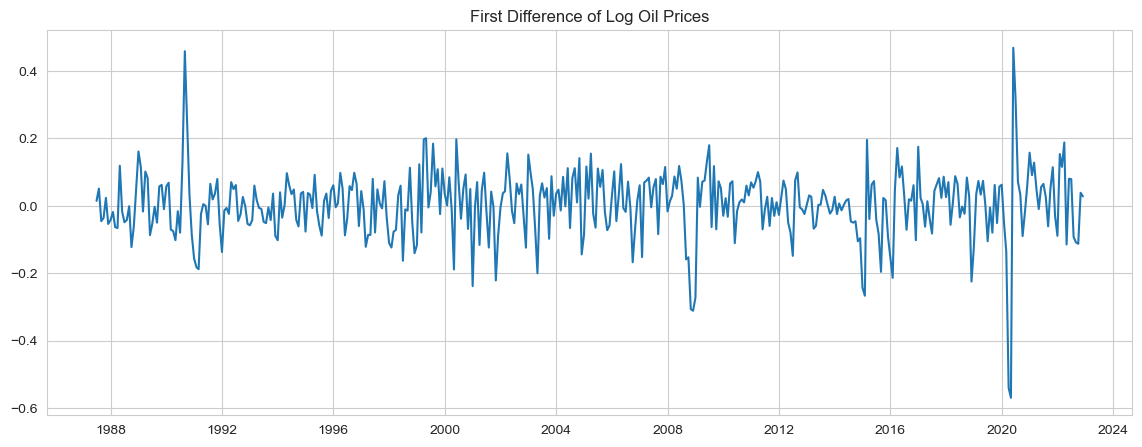

In [18]:
monthly_df['Diff_Log'] = (
    monthly_df['Log_Price']
    .diff()
)

plt.figure(figsize=(14,5))

plt.plot(
    monthly_df.index,
    monthly_df['Diff_Log']
)

plt.title(
    'First Difference of Log Oil Prices'
)

plt.grid(True)

plt.show()

In [19]:
result_diff = adfuller(
    monthly_df['Diff_Log'].dropna()
)

print(
    "ADF Statistic:",
    result_diff[0]
)

print(
    "P-value:",
    result_diff[1]
)

ADF Statistic: -11.480085058062691
P-value: 5.019287404474349e-21


After conducting a first-order difference to address non-stationarity using differencing, the p-value was brought down to less than 0.05, thus achieving stationarity. The time series is now suitable for ARIMA modeling.

<Figure size 1000x500 with 0 Axes>

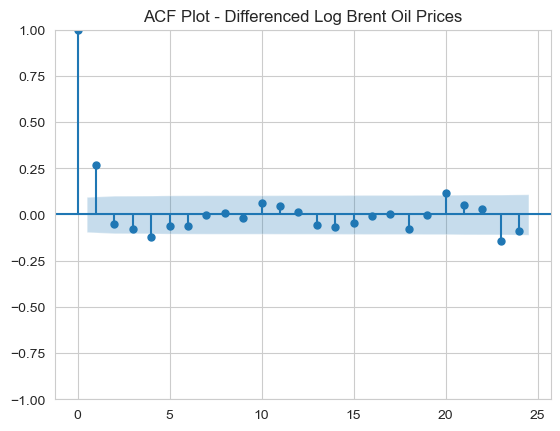

In [20]:
plt.figure(figsize=(10,5))

plot_acf(
    monthly_df['Diff_Log'].dropna(),
    lags=24
)

plt.title(
    'ACF Plot - Differenced Log Brent Oil Prices'
)

plt.show()

From the ACF plot we see that most lags fall within the confidence interval except for lag 1, which features a pretty strong spike.

<Figure size 1000x500 with 0 Axes>

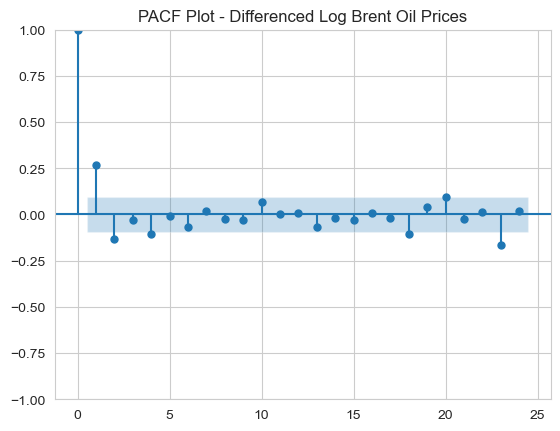

In [21]:
plt.figure(figsize=(10,5))

plot_pacf(
    monthly_df['Diff_Log'].dropna(),
    lags=24,
    method='ywm'
)

plt.title(
    'PACF Plot - Differenced Log Brent Oil Prices'
)

plt.show()

Like the ACF plot, this PACF plot shows that theres a strong spike at lag 1 which then drops, this indicates a low-order autoregressive pattern.

In [22]:
candidate_models = [
    (1,1,1),
    (2,1,1),
    (1,1,2),
    (2,1,2)
]

results = []

for order in candidate_models:

    model = ARIMA(
        monthly_df['Log_Price'],
        order=order
    )

    fitted = model.fit()

    results.append(
        [order, fitted.aic]
    )

aic_df = pd.DataFrame(
    results,
    columns=['ARIMA Order','AIC']
)

aic_df.sort_values(
    'AIC'
)

,ARIMA Order,AIC
2,"(1, 1, 2)",-789.512404
1,"(2, 1, 1)",-787.984201
3,"(2, 1, 2)",-787.521852
0,"(1, 1, 1)",-786.374074


Here were indentifying candidate ARIMA models using AIC (lowest = best), this will help us is better forecasting.

In [23]:
final_model = ARIMA(
    monthly_df['Log_Price'],
    order=(1,1,2)
)

final_result = final_model.fit()

print(final_result.summary())

                               SARIMAX Results                                
Dep. Variable:              Log_Price   No. Observations:                  427
Model:                 ARIMA(1, 1, 2)   Log Likelihood                 398.756
Date:                Sun, 31 May 2026   AIC                           -789.512
Time:                        13:06:26   BIC                           -773.295
Sample:                    05-31-1987   HQIC                          -783.106
                         - 11-30-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8784      0.064     13.761      0.000       0.753       1.004
ma.L1         -0.5864      0.079     -7.442      0.000      -0.741      -0.432
ma.L2         -0.3283      0.038     -8.711      0.0

Here we are training our ARIMA model on the log-transformed oil prices, and we're using the log-transformed prices because the variance is more stable and this improves model reliability.

In [24]:
forecast_steps = 12

forecast_result = final_result.get_forecast(
    steps=forecast_steps
)

forecast_mean_log = forecast_result.predicted_mean
forecast_ci_log = forecast_result.conf_int()

creating a 12 month forecast of oil prices.

In [25]:
forecast_mean = np.exp(forecast_mean_log)

forecast_ci = np.exp(forecast_ci_log)

Since our model used log-tranformed prices, we need to convert the forecast back to original format using exponentiation.

In [26]:
forecast_dates = pd.date_range(
    start=monthly_df.index[-1] + pd.offsets.MonthEnd(1),
    periods=forecast_steps,
    freq='M'
)

forecast_mean.index = forecast_dates
forecast_ci.index = forecast_dates

forecast_df = pd.DataFrame({
    'Forecasted_Price': forecast_mean,
    'Lower_CI': forecast_ci.iloc[:, 0],
    'Upper_CI': forecast_ci.iloc[:, 1]
})

forecast_df

,Forecasted_Price,Lower_CI,Upper_CI
2022-12-31,95.280591,79.113860,114.750957
2023-01-31,94.249923,69.558093,127.706893
2023-02-28,93.353769,63.894674,136.395191
2023-03-31,92.573608,59.862738,143.158717
2023-04-30,91.893682,56.766936,148.756466
2023-05-31,91.300547,54.282718,153.562499
2023-06-30,90.782687,52.228452,157.797062
2023-07-31,90.330215,50.491237,161.603246
2023-08-31,89.934618,48.995879,165.079915
2023-09-30,89.588549,47.689782,168.298275


Creating dates for the forecasts and a forecast table.

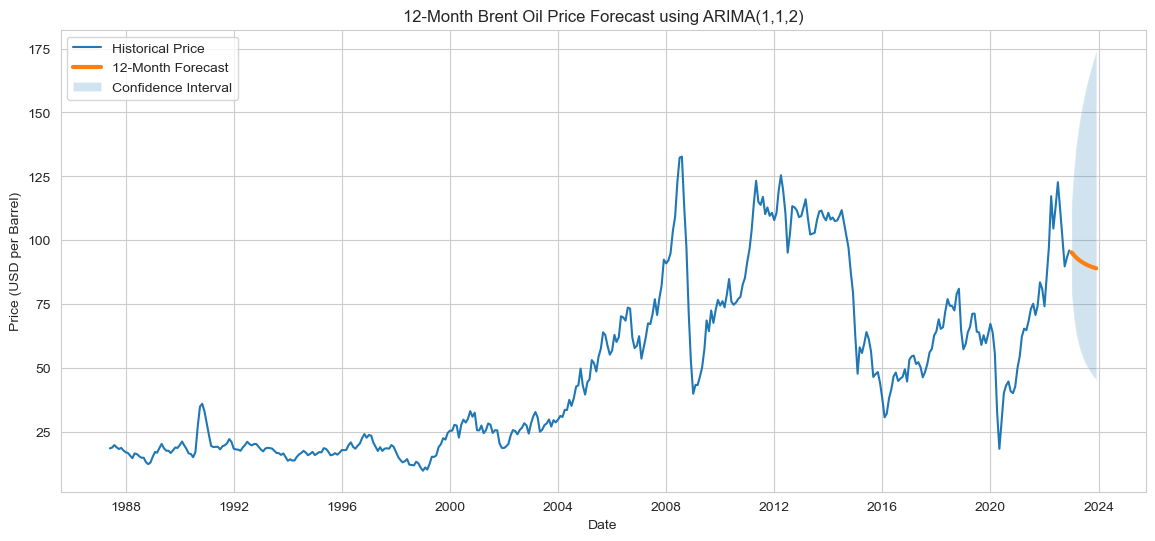

In [27]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_df.index,
    monthly_df['Price'],
    label='Historical Price'
)

plt.plot(
    forecast_df.index,
    forecast_df['Forecasted_Price'],
    label='12-Month Forecast',
    linewidth=3
)

plt.fill_between(
    forecast_df.index,
    forecast_df['Lower_CI'],
    forecast_df['Upper_CI'],
    alpha=0.2,
    label='Confidence Interval'
)

plt.title('12-Month Brent Oil Price Forecast using ARIMA(1,1,2)')
plt.xlabel('Date')
plt.ylabel('Price (USD per Barrel)')

plt.legend()
plt.grid(True)

plt.show()

From the plot, we notice that the model suggests a decline in oil prices over the next 12 months, indicating the model also recognized that the 2022 spike was most likely to not persist.

We also see that over time, the confidence interval widens. This is expected since oil prices are volatile and economic events cannot be predicted by the model.

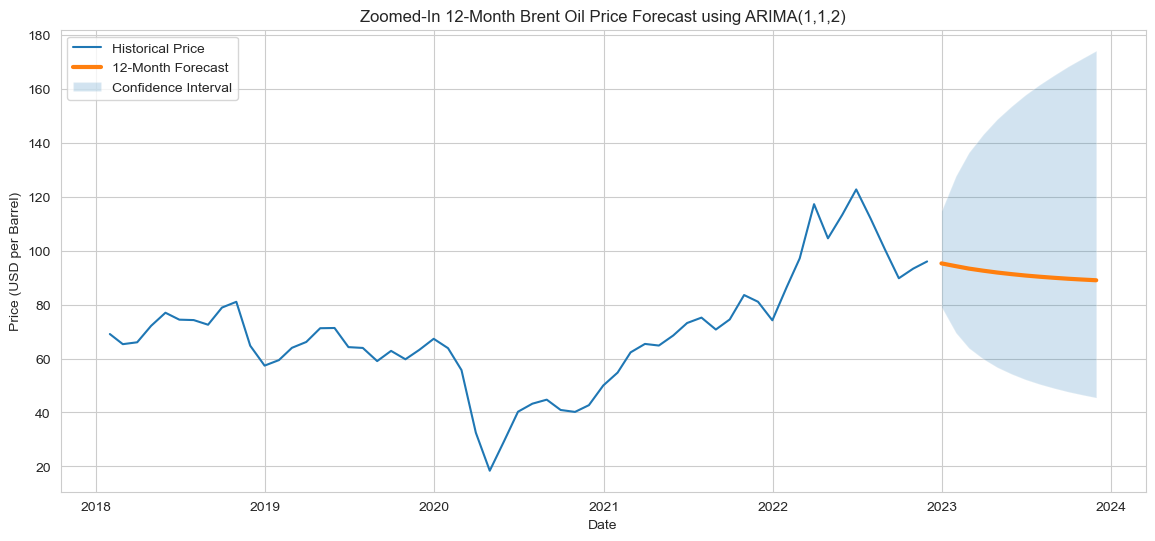

In [28]:
# Zoomed-in forecast plot from 2018 onward

zoom_start_date = '2018-01-01'

plt.figure(figsize=(14,6))

plt.plot(
    monthly_df.loc[zoom_start_date:].index,
    monthly_df.loc[zoom_start_date:]['Price'],
    label='Historical Price'
)

plt.plot(
    forecast_df.index,
    forecast_df['Forecasted_Price'],
    label='12-Month Forecast',
    linewidth=3
)

plt.fill_between(
    forecast_df.index,
    forecast_df['Lower_CI'],
    forecast_df['Upper_CI'],
    alpha=0.2,
    label='Confidence Interval'
)

plt.title('Zoomed-In 12-Month Brent Oil Price Forecast using ARIMA(1,1,2)')
plt.xlabel('Date')
plt.ylabel('Price (USD per Barrel)')

plt.legend()
plt.grid(True)

plt.show()